# Chapter 18: TorchDEQ, DeltaDEQ, and Efficient Solver Engineering

This solved notebook is the executable counterpart to Chapter 18. It starts
with hand-sized arrays, then carries the same equilibrium contract into
TorchDEQ and DeltaDEQ solver behavior.

Goal: dimension-wise convergence masks and cached linear operations in a toy DEQ.

Book context:

- Story: Practical DEQ models live or die by solver engineering. TorchDEQ packages the abstraction, while DeltaDEQ observes that different coordinates settle at different speeds.
- State: the solver state split into converged and unconverged coordinate blocks
- Source: residual traces and cached linear-operation outputs
- Operator: the implemented DEQ solver map and its blockwise convergence mask
- Where it is used: fast inference, reusable DEQ code, memory-aware training, and production-style SILVA solvers

Progression in this notebook:

1. Build a NumPy miniature where every vector, residual, and Jacobian is visible.
2. Rebuild the same map in PyTorch and compare the settled states.
3. Compute derivatives by finite differences, full autograd, VJP/JVP, power iteration, and Hutchinson probes.
4. Derive the mean-field branch from empirical averaging before using its matrix form.
5. Run a tiny SILVA-style layer or the chapter's dataset/project path.
6. Close with the chapter-specific project or recent-paper cell when applicable.

Primary implementation and tutorial references:

- Locus Lab DEQ repo: https://github.com/locuslab/deq
- TorchDEQ repo: https://github.com/locuslab/torchdeq
- Deep Implicit Layers tutorial Colabs: https://implicit-layers-tutorial.org/
- DEQ paper: https://arxiv.org/abs/1909.01377
- MDEQ paper: https://arxiv.org/abs/2006.08656
- Jacobian regularization paper: https://arxiv.org/abs/2106.14342
- Numbered research references: https://jseluis.github.io/silva-networks/paper/references/


In [1]:

import sys
from pathlib import Path

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "silva_networks").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not find suite root containing src/silva_networks")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
from silva_networks import (
    np_picard,
    np_finite_difference_jacobian,
    np_exact_tanh_affine_jacobian,
    np_power_iteration,
    np_implicit_gradient,
    SolverConfig,
    picard,
    anderson,
    torch_full_jacobian,
    torch_vjp,
    torch_jvp,
    TinySILVALayer,
    spectral_radius_vjp,
    hutchinson_jacobian_frobenius,
)

np.random.seed(7)
torch.manual_seed(7)
torch.set_default_dtype(torch.float64)


## 1. NumPy miniature: TorchDEQ and DeltaDEQ solver behavior


NumPy z*: [ 0.56330034  0.30026557  0.37251161 -0.85858069]
NumPy final residual: 7.586540292229797e-11
||J_exact - J_fd||_F: 9.766943378216947e-12
materialized damped spectral-radius estimate: 0.4694673980561897


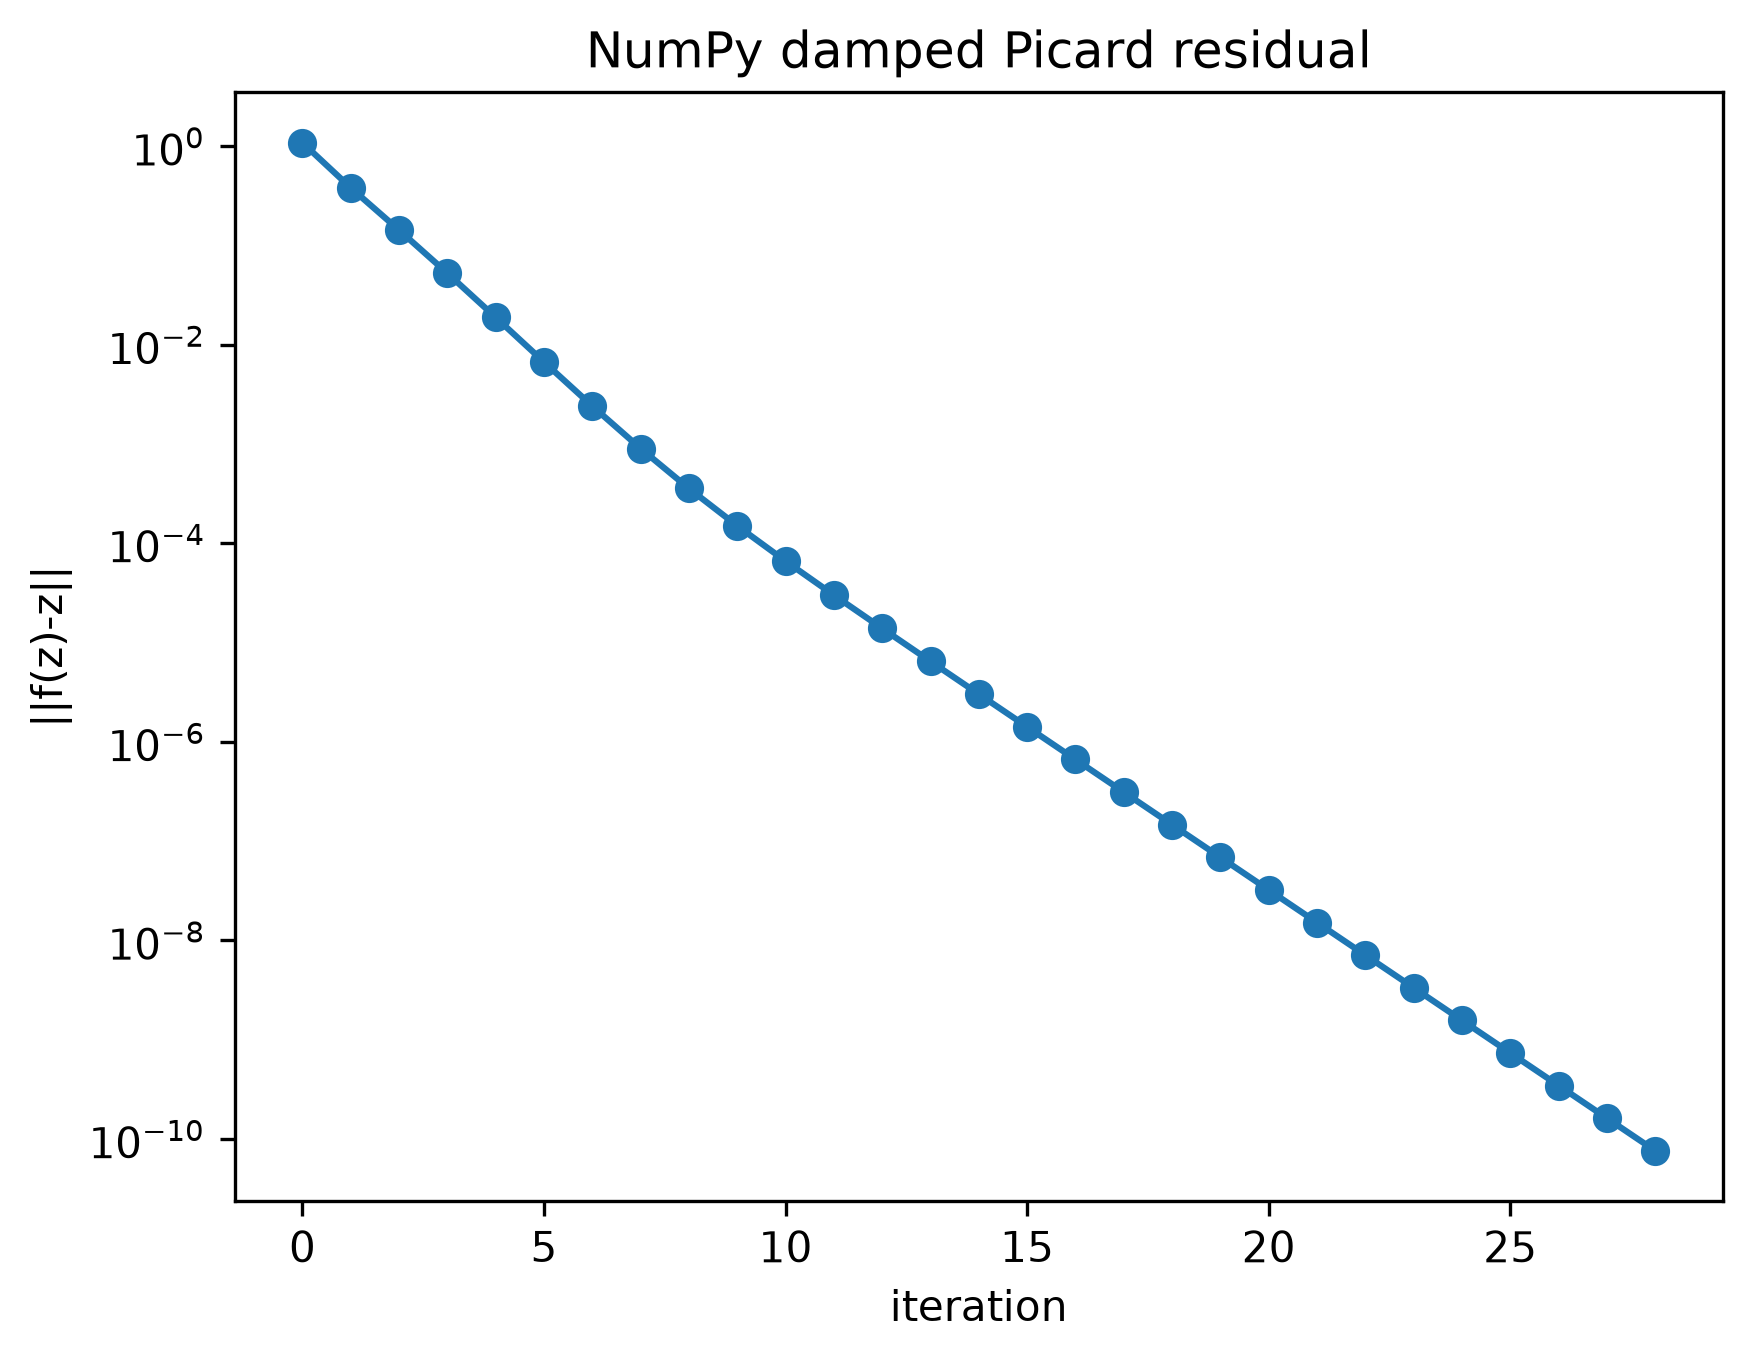

In [2]:

# NumPy first: a tiny fixed-point layer f(z)=tanh(Wz+s).
n = 4
W_np = 0.35 * np.random.randn(n, n) / np.sqrt(n)
s_np = np.random.randn(n)

def f_np(z):
    return np.tanh(W_np @ z + s_np)

z0_np = np.zeros(n)
trace_np = np_picard(f_np, z0_np, alpha=0.7, max_iter=80, tol=1e-10)
print("NumPy z*:", trace_np.z)
print("NumPy final residual:", trace_np.residuals[-1])

J_exact = np_exact_tanh_affine_jacobian(W_np, trace_np.z, s_np)
J_fd = np_finite_difference_jacobian(f_np, trace_np.z, eps=1e-5)
print("||J_exact - J_fd||_F:", np.linalg.norm(J_exact - J_fd))

T_np = (1 - 0.7) * np.eye(n) + 0.7 * J_exact
rho_np, _ = np_power_iteration(T_np)
print("materialized damped spectral-radius estimate:", rho_np)

plt.plot(trace_np.residuals, marker="o")
plt.yscale("log")
plt.title("NumPy damped Picard residual")
plt.xlabel("iteration")
plt.ylabel("||f(z)-z||")
plt.show()


## 2. PyTorch mirror: TorchDEQ and DeltaDEQ solver behavior


PyTorch z*: [ 0.56330034  0.30026557  0.37251161 -0.85858069]
PyTorch final residual: 7.586541579942792e-11
NumPy/PyTorch state difference: 1.5700924586837752e-16
PyTorch full Jacobian shape: (4, 4)
||J_torch - J_exact||_F: 5.764530744520761e-17


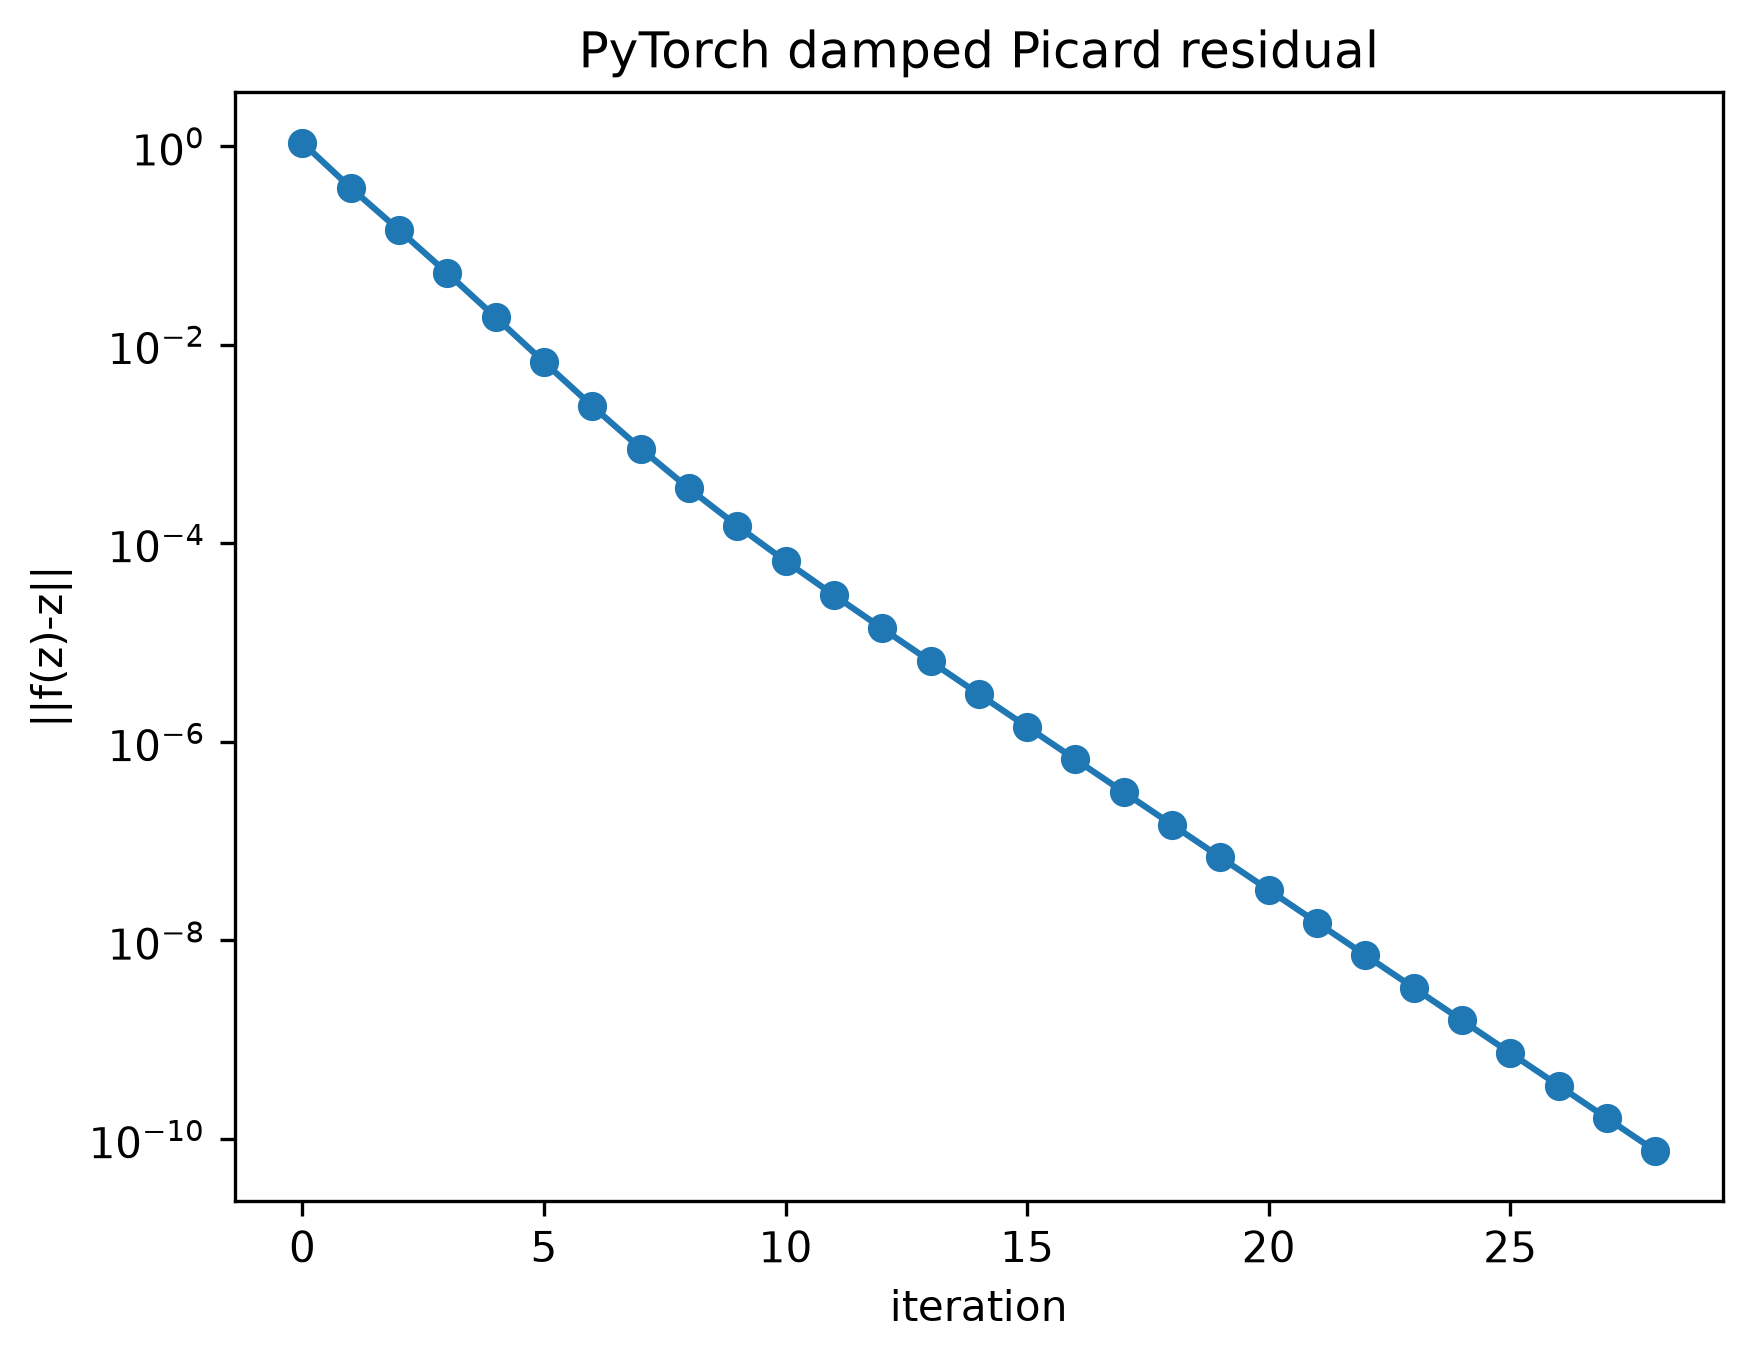

In [3]:

# PyTorch mirror: same W and s, now with autograd.
W = torch.tensor(W_np)
s = torch.tensor(s_np)

def f_torch(z):
    return torch.tanh(W @ z + s)

dim = n
z0 = torch.zeros(n)
trace = picard(
    f_torch,
    z0,
    SolverConfig(alpha=0.7, max_iter=80, tol=1e-10),
)
print("PyTorch z*:", trace.z.detach().numpy())
print("PyTorch final residual:", trace.residuals[-1])
print("NumPy/PyTorch state difference:", np.linalg.norm(trace_np.z - trace.z.detach().numpy()))

J_torch = torch_full_jacobian(f_torch, trace.z)
print("PyTorch full Jacobian shape:", tuple(J_torch.shape))
print("||J_torch - J_exact||_F:", torch.linalg.norm(J_torch - torch.tensor(J_exact)).item())

plt.plot(trace.residuals, marker="o")
plt.yscale("log")
plt.title("PyTorch damped Picard residual")
plt.xlabel("iteration")
plt.ylabel("||f(z)-z||")
plt.show()


## 3. Jacobian products and stability for Chapter 18


In [4]:

# Scalable Jacobian operations: VJP, JVP, spectral radius, and Hutchinson.
z_star = trace.z.detach()
v = torch.randn_like(z_star)
v = v / torch.linalg.norm(v)

jtv = torch_vjp(f_torch, z_star, v)
_, jv = torch_jvp(f_torch, z_star, v)
print("VJP shape:", tuple(jtv.shape), "JVP shape:", tuple(jv.shape))

rho_torch = spectral_radius_vjp(
    lambda zz: (1 - 0.7) * zz + 0.7 * f_torch(zz),
    z_star,
    iters=50,
)
print("VJP damped spectral-radius estimate:", rho_torch)
print("materialized NumPy estimate:", rho_np)

jac_frob_est = hutchinson_jacobian_frobenius(f_torch, z_star, samples=8)
jac_frob_exact = torch.linalg.norm(J_torch) ** 2
print("Hutchinson estimate of ||J||_F^2:", float(jac_frob_est))
print("Exact ||J||_F^2 for this small case:", float(jac_frob_exact))


VJP shape: (4,) JVP shape: (4,)
VJP damped spectral-radius estimate: 0.46946739795791165
materialized NumPy estimate: 0.4694673980561897
Hutchinson estimate of ||J||_F^2: 0.19709954158535606
Exact ||J||_F^2 for this small case: 0.18666150175498958


## 4. Implicit-gradient adjoint check for Chapter 18


In [5]:

# Verify the implicit-gradient equation on a scalar parameter.
a = torch.tensor(0.35, requires_grad=True)
b = torch.tensor(1.2)

def scalar_solve(a):
    z = torch.zeros(())
    for _ in range(80):
        z = torch.tanh(a * z + b)
    return z

z_star = scalar_solve(a)
loss = 0.5 * z_star ** 2
loss.backward()

with torch.no_grad():
    jf = a * (1 - torch.tanh(a * z_star + b) ** 2)
    df_da = z_star * (1 - torch.tanh(a * z_star + b) ** 2)
    implicit_grad = z_star * df_da / (1 - jf)
print("autograd through finite solve:", float(a.grad))
print("implicit formula:", float(implicit_grad))

# The same adjoint idea with a materialized NumPy Jacobian.
g_np = trace_np.z.copy()  # gradient of 0.5 ||z*||^2 with respect to z*
df_dscale = (1 - np.tanh(W_np @ trace_np.z + s_np) ** 2)[:, None] * (W_np @ trace_np.z)[:, None]
grad_scale = np_implicit_gradient(J_exact, g_np, df_dscale)
print("NumPy adjoint gradient for scaling W:", grad_scale)


autograd through finite solve: 0.15374203229105038
implicit formula: 0.1537420322910504
NumPy adjoint gradient for scaling W: [0.07249599]


## 5. Mean-field branch for TorchDEQ and DeltaDEQ solver behavior

This cell derives the global branch from the empirical average and verifies the compact matrix form before using `MeanFieldGlobal` inside the SILVA layer.


In [6]:

# From scratch: derive and verify the mean-field global term.
# Start with entity states Y: rows are nodes/atoms/channels, columns are features.
N, d, d_out = 5, 3, 2
Y = np.random.randn(N, d)
Wg = np.random.randn(d_out, d)

# 1. Literal empirical mean from the definition: \bar y = (1/N) sum_j y_j.
g_loop = np.zeros(d)
for j in range(N):
    g_loop = g_loop + Y[j]
g_loop = g_loop / N

# 2. Broadcast the same global context to every entity and mix channels.
out_loop = np.zeros((N, d_out))
for i in range(N):
    out_loop[i] = g_loop @ Wg.T

# 3. Matrix form: G(Y) = (1/N) 1 1^T Y W_g^T.
one = np.ones((N, 1))
P_global = (one @ one.T) / N
out_matrix = P_global @ Y @ Wg.T

print("loop/matrix agreement:", np.linalg.norm(out_loop - out_matrix))
print("rank of node-space mean-field matrix:", np.linalg.matrix_rank(P_global))

# 4. Permutation equivariance: G(Pi Y) = Pi G(Y).
perm = np.array([2, 0, 4, 1, 3])
Pi = np.eye(N)[perm]
lhs = P_global @ (Pi @ Y) @ Wg.T
rhs = Pi @ (P_global @ Y @ Wg.T)
print("permutation equivariance error:", np.linalg.norm(lhs - rhs))

# 5. Batch version: means must be computed inside each graph/sample.
batch = np.array([0, 0, 0, 1, 1])
out_batch = np.zeros((N, d_out))
for b_id in np.unique(batch):
    mask = batch == b_id
    gb = Y[mask].mean(axis=0, keepdims=True)
    out_batch[mask] = gb @ Wg.T
print("batch-local global term shape:", out_batch.shape)


loop/matrix agreement: 9.309503074677274e-17
rank of node-space mean-field matrix: 1
permutation equivariance error: 2.5589376332604516e-16
batch-local global term shape: (5, 2)


## 6. SILVA smoke test: dimension-wise convergence masks and cached linear operations in a toy DEQ


In [7]:

# Tiny SILVA layer smoke example.
x = torch.randn(8, 3)
edge_index = torch.tensor([[0,1,2,3,4,5,6,7], [1,2,3,4,5,6,7,0]])
layer = TinySILVALayer(in_dim=3, hidden_dim=12, alpha=0.4, max_iter=20)
z, residuals = layer(x, edge_index=edge_index, return_trace=True)
print("state shape:", tuple(z.shape))
print("last residual:", residuals[-1])
rho = spectral_radius_vjp(lambda zz: (1-layer.alpha)*zz + layer.alpha*layer.f(zz, x, edge_index=edge_index), z)
print("damped spectral radius estimate:", rho)


state shape: (8, 12)
last residual: 0.0187884016129055
damped spectral radius estimate: 0.7756974957671103


## Chapter-specific recent-paper implementation: TorchDEQ, DeltaDEQ, and Efficient Solver Engineering


approx state: [1.052625   1.17638125 1.66659676 3.57116827 8.33259534]
true state: [1.05263158 1.17647059 1.66666667 3.57142857 8.33333333]
active coordinates after solve: [False False False False False]


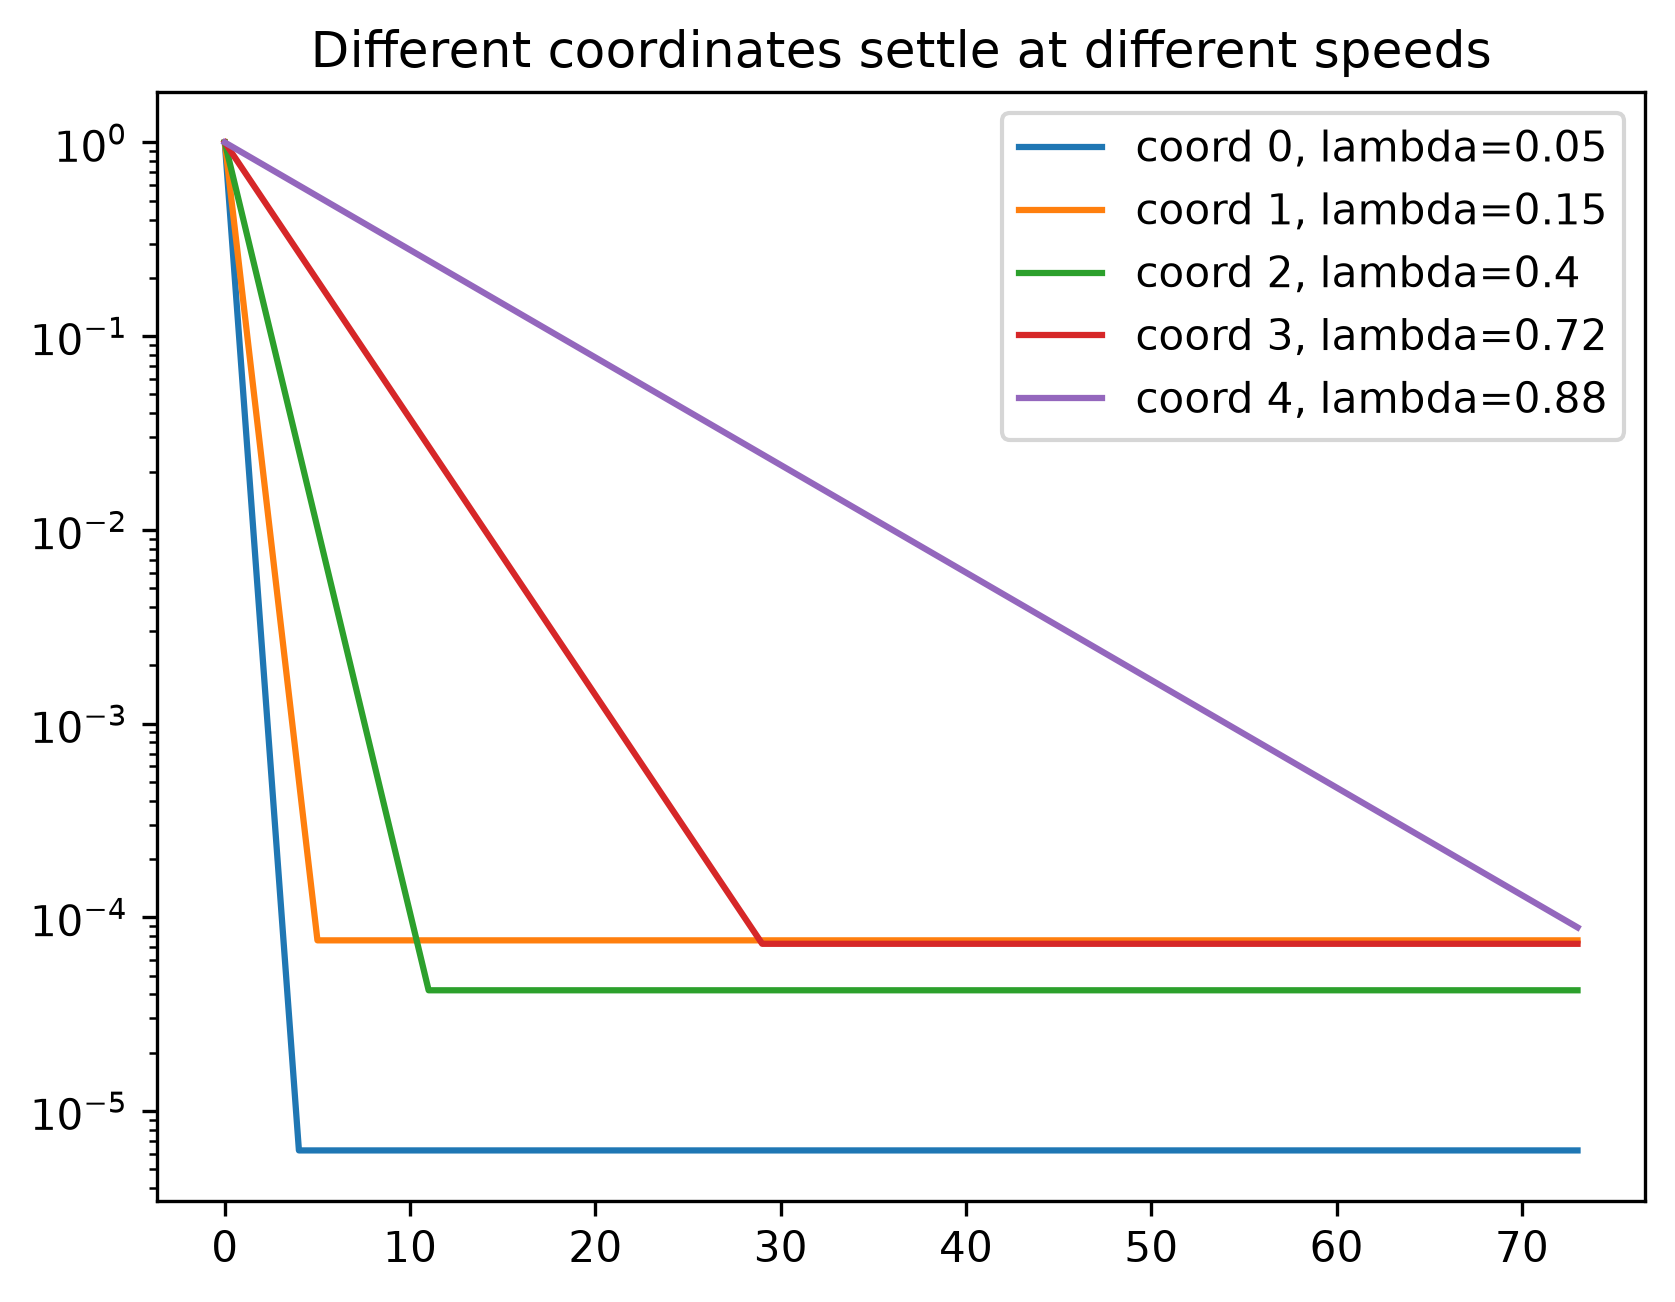

In [8]:

# Chapter 18: heterogeneous convergence and a DeltaDEQ-style mask.
lam = np.array([0.05, 0.15, 0.4, 0.72, 0.88])
s = np.ones_like(lam)
z = np.zeros_like(lam)
active = np.ones_like(lam, dtype=bool)
history = []
tol_coord = 1e-4
for k in range(80):
    proposed = s + lam * z
    coord_res = np.abs(proposed - z)
    newly_done = coord_res < tol_coord
    active = active & (~newly_done)
    z = np.where(active, proposed, z)
    history.append(coord_res.copy())
    if not active.any():
        break
history = np.asarray(history)
z_star = s / (1 - lam)
print("approx state:", z)
print("true state:", z_star)
print("active coordinates after solve:", active)

for i in range(len(lam)):
    plt.semilogy(history[:, i], label=f"coord {i}, lambda={lam[i]}")
plt.legend()
plt.title("Different coordinates settle at different speeds")
plt.show()


## Data and project path for Chapter 18

For quick experiments, use the companion cache under `data/cache/`.

- Vision: MNIST, Fashion-MNIST, CIFAR-10 small subsets.
- Molecules: ZINC-12k smoke subsets.
- Graphs: Cora/Citeseer/Pubmed public splits and CLUSTER smoke batches.

Downloader:

```bash
python data/download_datasets.py mnist fashion cifar10 zinc planetoid cluster
```

For Chapter 18, the mini-project focus is: **dimension-wise convergence masks and cached linear operations in a toy DEQ**.


## Chapter 18 solved notebook summary

The implementation target is **dimension-wise convergence masks and cached linear operations in a toy DEQ**. The cells above construct an
equilibrium in NumPy, repeat it in PyTorch, compute Jacobians by several
methods, verify an implicit derivative, and run a tiny SILVA-style local/global
layer. This is the executable baseline for scaling the chapter to the article's
full experiments.


## From 18 Torchdeq Deltadeq to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 1.621736402640195e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '18_torchdeq_deltadeq.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '18_torchdeq_deltadeq.ipynb',
 'state': 'the tensor solved to equilibrium',
 'condition': 'the observed input or source tensor',
 'transition': 'the state-preserving transition evaluated by the root solver',
 'invariants': 'shape, device, dtype, finiteness, and differentiability',
 'compact_metric': 'fixed-point residual and task error against a deterministic target',
 'scale_axis': 'state width, batch size, and data volume'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the tensor solved to equilibrium**, and its repeated map,
**the state-preserving transition evaluated by the root solver**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 7.168e-09 | 1.792e-09 | 1.2500 | 0.000e+00
0.45 |  23 | 8.218e-09 | 6.723e-09 | 1.8182 | 0.000e+00
0.70 |  50 | 8.992e-09 | 2.098e-08 | 3.3333 | 0.000e+00
0.85 | 108 | 9.815e-09 | 5.562e-08 | 6.6667 | 0.000e+00


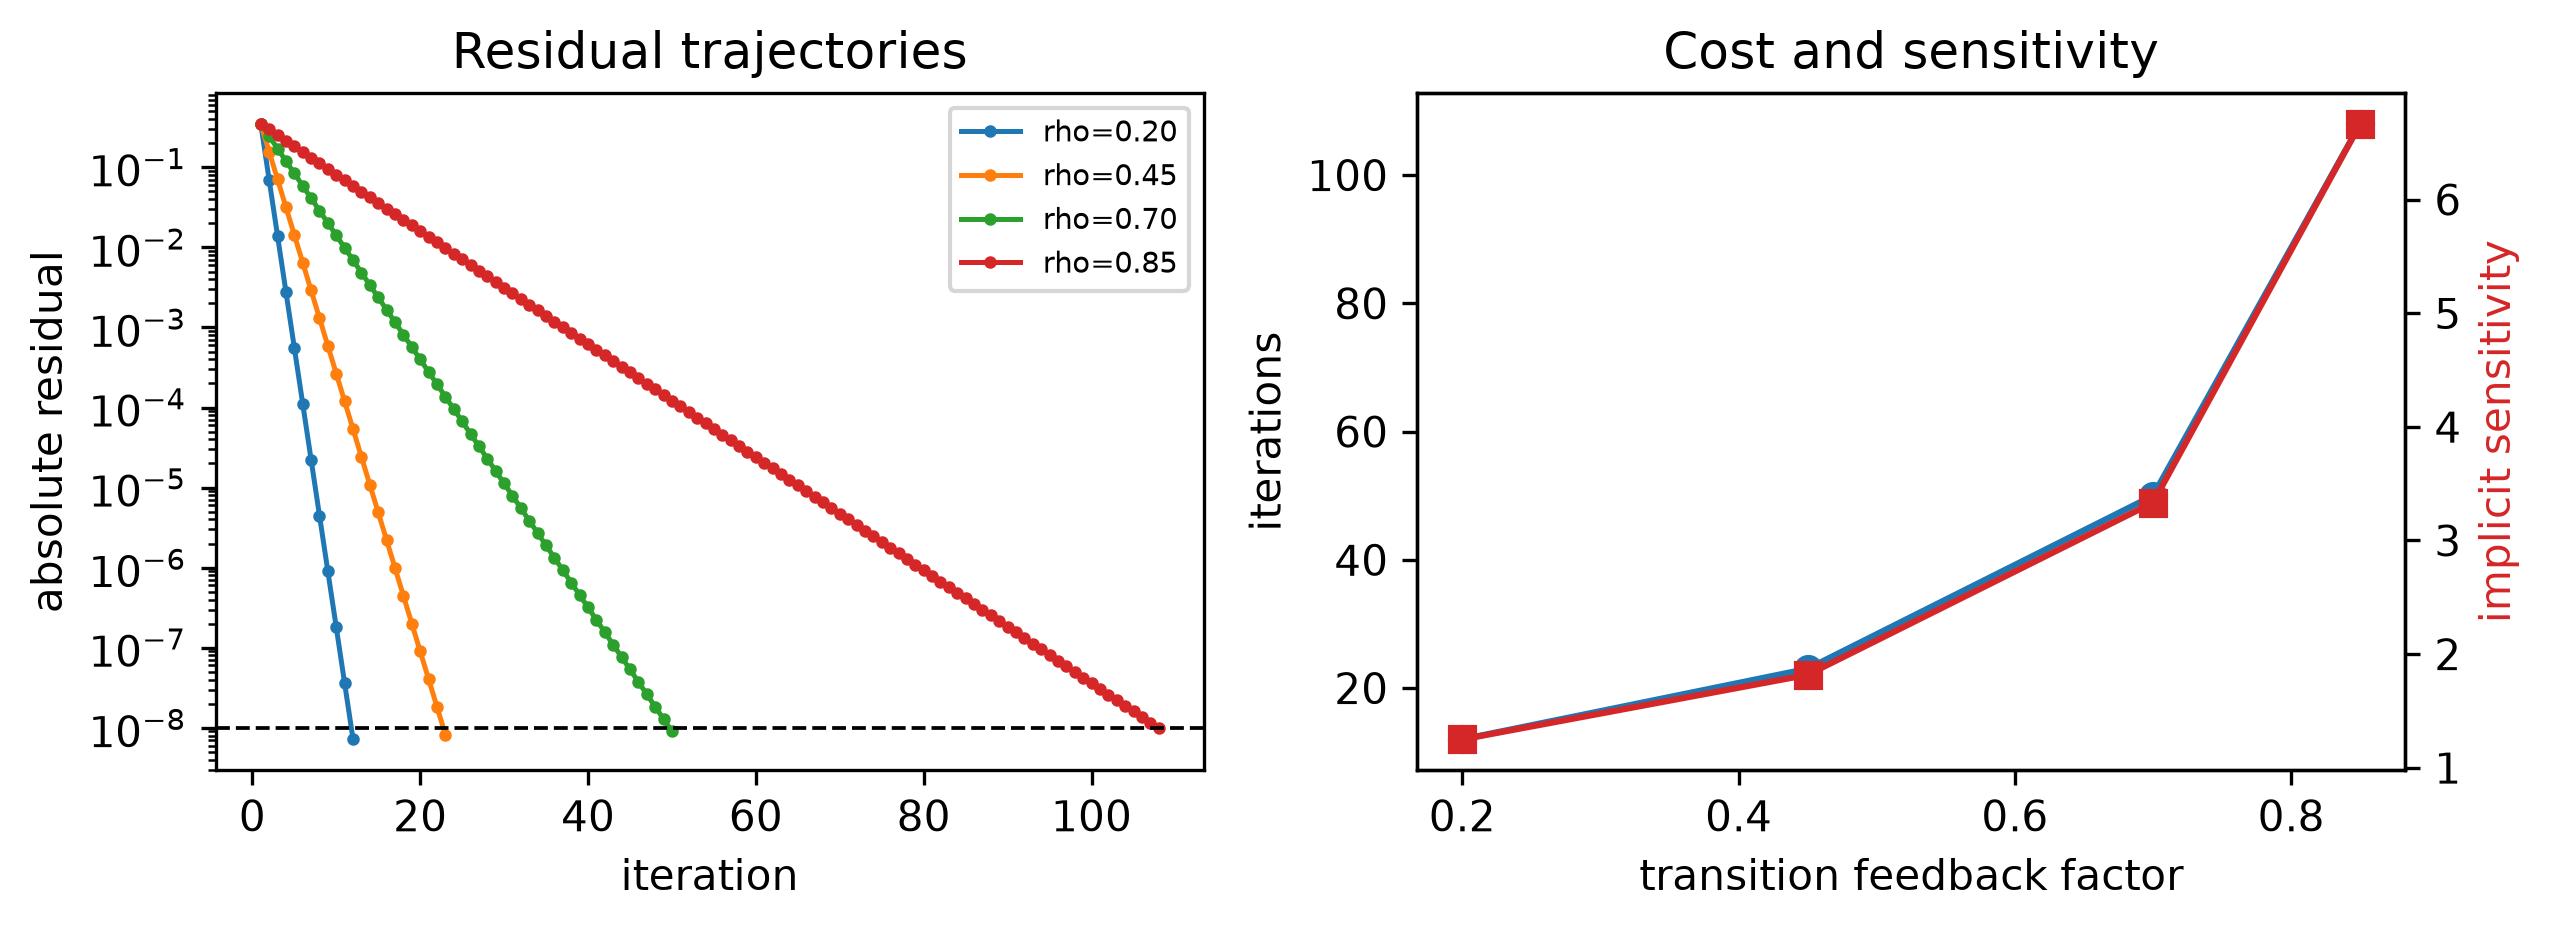

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | fixed-point residual and task error against a deterministic target |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | shape, device, dtype, finiteness, and differentiability |
| Scale sweep | Change one of state width, batch size, and data volume at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.
